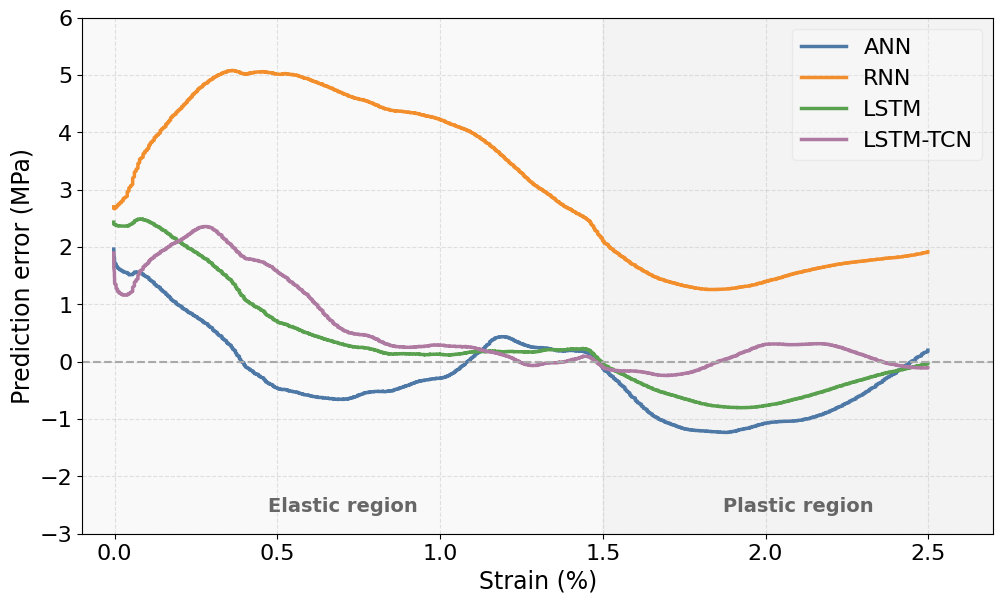

saved: ann_fig/prediction/residual_trends_combined.png


In [40]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 手动可调
STRAIN_MAX = 2.5
X_RANGE    = (-0.1, 2.7)
Y_LIMIT    = (-3, 6)   # 设为 None 则自适应

# 四个模型残差CSV路径（按你保存的位置改）
series = [
    {'name': 'ANN',      'csv': 'ann_fig/prediction/residuals_ANN.csv',         'color': '#4E79A7'},
    {'name': 'RNN',      'csv': 'rnn_fig/prediction/residuals_RNN.csv',         'color': '#F28E2B'},
    {'name': 'LSTM',     'csv': 'lstm_fig/prediction/residuals_LSTM.csv',       'color': '#59A14F'},
    {'name': 'LSTM-TCN', 'csv': 'lstmtcn_fig/prediction/residuals_LSTMTCN.csv', 'color': '#AF7AA1'},
]

plt.figure(figsize=(10, 6))
for s in series:
    if not os.path.exists(s['csv']):
        print('skip (not found):', s['csv']); continue
    df = pd.read_csv(s['csv']).dropna()
    df = df[df['strain'] <= STRAIN_MAX].sort_values('strain')
    if len(df) < 5:
        print('skip (too few points):', s['name']); continue

    x = df['strain'].values
    y = df['residual'].values

    # 平滑（自适应窗口）
    n = len(y)
    if n >= 11:
        win = min(101, max(11, (n // 10) * 2 + 1))
        poly = 2 if win > 3 else 1
        y_smooth = savgol_filter(y, win, poly)
    else:
        y_smooth = y

    plt.plot(x, y_smooth, color=s['color'], linewidth=2.5, label=s['name'])


# 零误差参考线
plt.axhline(0, color='#A9A9A9', linestyle='--', linewidth=1.5)

plt.xlabel('Strain (%)', fontsize=17)
plt.ylabel('Prediction error (MPa)', fontsize=17)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle='--', alpha=0.35)
plt.legend(fontsize=16, loc='upper right',
                 frameon=True, facecolor='white', framealpha=0.25)

plt.xlim(*X_RANGE)
if Y_LIMIT is not None:
    plt.ylim(*Y_LIMIT)
# 
ax = plt.gca()
ax.axvspan(-0.1, 1.5, color='#F5F5F5', alpha=0.5, zorder=0)  # Elastic Region
ax.axvspan(1.5, 2.7, color='#E8E8E8', alpha=0.5, zorder=0)  # Plastic Region

ax = plt.gca()
# x 用数据坐标，y 用轴分数坐标（0=底部，1=顶部）
trans = ax.get_xaxis_transform()

ax.text(0.7, 0.035, 'Elastic region', transform=trans, ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#666666')

ax.text(2.1, 0.035, 'Plastic region', transform=trans, ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='#666666')
# 

os.makedirs('ann_fig/prediction', exist_ok=True)
out_path = os.path.join('ann_fig', 'prediction', 'residual_trends_combined.png')
plt.tight_layout(pad=0.6)
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print('saved:', out_path)